In [17]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import shutil

In [18]:
base_path = Path("..")

print("Train images:", len(list((base_path / "train/images").glob("*"))))
print("Train labels:", len(list((base_path / "train/labels").glob("*.txt"))))
print("Test images:", len(list((base_path / "test/images").glob("*"))))
print("Test labels:", len(list((base_path / "test/labels").glob("*.txt"))))

Train images: 1323
Train labels: 1323
Test images: 403
Test labels: 403


In [19]:
label_paths = list(Path("../train/labels").glob("*.txt")) + list(Path("../test/labels").glob("*.txt"))

class_ids = Counter()

for label_file in label_paths:
    with open(label_file, "r") as f:
        for line in f:
            if line.strip():
                class_id = line.split()[0]
                class_ids[class_id] += 1

print("Class IDs found:")
print(class_ids)

Class IDs found:
Counter({'1': 1915, '2': 726, '4': 658, '3': 497, '0': 177})


In [20]:
yaml_path = Path("../dataset/safety-helmet-dataset.yaml")

yaml_content = """path: E:/CODTECH_PROJECTS/Safety-Helmet-Detection-YOLOv8

train: train/images
val: test/images
test: test/images

nc: 3
names:
  0: helmet
  1: head
  2: person
"""

yaml_path.write_text(yaml_content)

print("YAML file created successfully")
print(yaml_path.read_text())

YAML file created successfully
path: E:/CODTECH_PROJECTS/Safety-Helmet-Detection-YOLOv8

train: train/images
val: test/images
test: test/images

nc: 3
names:
  0: helmet
  1: head
  2: person



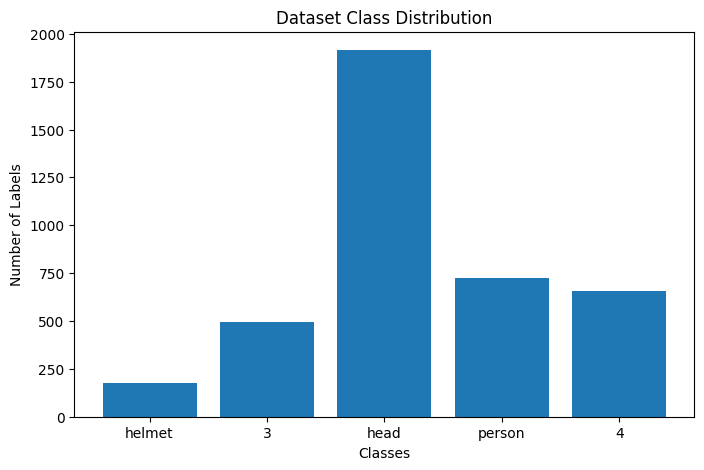

In [21]:
class_names = {
    "0": "helmet",
    "1": "head",
    "2": "person"
}

labels = [class_names.get(k, k) for k in class_ids.keys()]
values = list(class_ids.values())

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title("Dataset Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Labels")
plt.show()

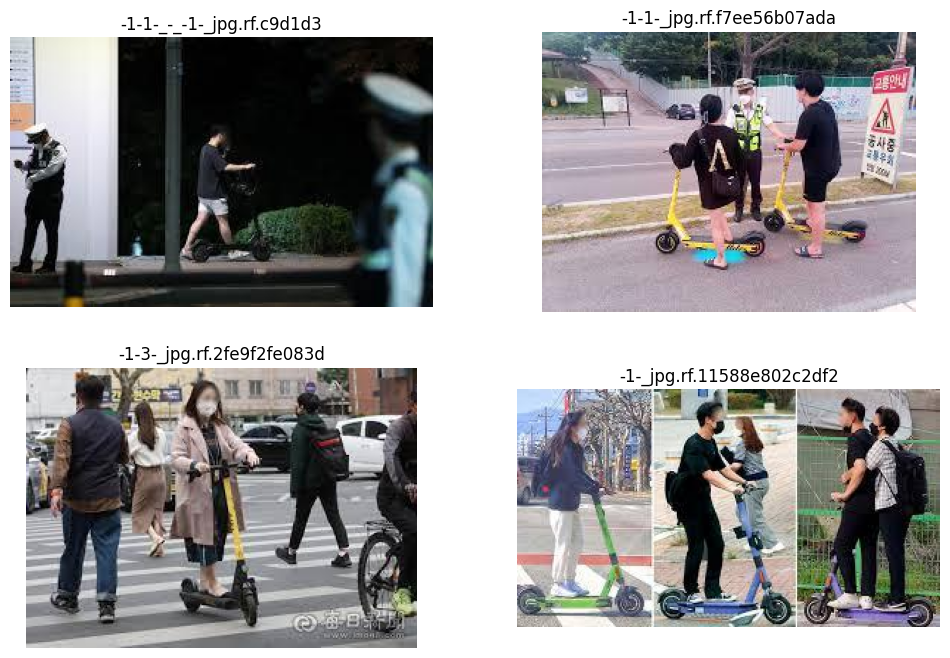

In [22]:
sample_images = list(Path("../train/images").glob("*"))[:4]

plt.figure(figsize=(12, 8))

for i, img_path in enumerate(sample_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(img_path.name[:25])
    plt.axis("off")

plt.show()

In [23]:
for i, img_path in enumerate(sample_images):
    label_path = Path("../train/labels") / (img_path.stem + ".txt")
    if label_path.exists():
        with open(label_path, "r") as f:
            for line in f:
                if line.strip():
                    class_id, x_center, y_center, width, height = line.split()
                    class_name = class_names.get(class_id, class_id)
                    print(f"Image: {img_path.name}, Class: {class_name}, Box: ({x_center}, {y_center}, {width}, {height})")

Image: -1-1-_-_-1-_jpg.rf.c9d1d3f23bb916d85a19bcb0bc96cb9f.jpg, Class: helmet, Box: (0.49740213523131677, 0.37737430167597763, 0.05238434163701068, 0.11335195530726257)
Image: -1-1-_jpg.rf.f7ee56b07ada7333c1f340f8a966e851.jpg, Class: helmet, Box: (0.4355212355212355, 0.27675257731958763, 0.09274131274131274, 0.13907216494845362)
Image: -1-1-_jpg.rf.f7ee56b07ada7333c1f340f8a966e851.jpg, Class: helmet, Box: (0.7094980694980695, 0.20345360824742267, 0.12293436293436294, 0.15628865979381443)
Image: -1-3-_jpg.rf.2fe9f2fe083df955813f8972ee395bf3.jpg, Class: helmet, Box: (0.45633962264150946, 0.10510526315789473, 0.09879245283018868, 0.1647894736842105)
Image: -1-_jpg.rf.11588e802c2df233498429a9b2bbc5a5.jpg, Class: helmet, Box: (0.45341137123745817, 0.1355952380952381, 0.07481605351170569, 0.1500595238095238)
Image: -1-_jpg.rf.11588e802c2df233498429a9b2bbc5a5.jpg, Class: helmet, Box: (0.797190635451505, 0.12511904761904763, 0.051237458193979936, 0.1542261904761905)
Image: -1-_jpg.rf.11588e802

In [24]:
model = YOLO("yolov8n.pt")
print("YOLOv8 model loaded successfully")

YOLOv8 model loaded successfully


In [26]:
training_results = model.train(
    data="../dataset/safety-helmet-dataset.yaml",
    epochs=10,
    imgsz=640,
    batch=8,
    patience=10,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    project="../runs/detect",
    name="helmet_detection_advanced",
    exist_ok=True
)

Ultralytics 8.3.0  Python-3.10.20 torch-2.12.1+cpu CPU (11th Gen Intel Core(TM) i7-1165G7 2.80GHz)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=../dataset/safety-helmet-dataset.yaml, epochs=10, time=None, patience=10, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=../runs/detect, name=helmet_detection_advanced, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_

train: Scanning E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\train\labels.cache... 1323 images, 0 backgrounds, 652 corrupt: 100%|██████████| 1323/1323 [00:00<?, ?it/s]

train: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\train\images\0008b4d9bb7efcd9_jpg.rf.8e5829a45f27bba27e307bb3f247d3ab.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
train: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\train\images\036b89de96ab8338_jpg.rf.70c0514bb27f2298825220fa32075854.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
train: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\train\images\075720bb5ab9b63b_jpg.rf.0f5a55cfcdc0540f7dd7475007b5f002.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
train: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\train\images\0be9884e314b89b8_jpg.rf.32af9d3bbe6cf6682ee79386253539da.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
train: WARNI


c:\Users\Lenovo\anaconda3\envs\venv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
val: Scanning E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\test\labels.cache... 403 images, 0 backgrounds, 203 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]

val: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\test\images\00c5b5728ea00975_jpg.rf.83d084c1f35d45c90a3539332e483885.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
val: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\test\images\01907ca8f0e93d1bc7bffcd6d0f50239_jpg.rf.899067ffd6578d3f4be719c7eea07e4c.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
val: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\test\images\0b36b9c564f70e75_jpg.rf.ae80b25f2a980e5acd393ace07838bda.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
val: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\test\images\1025_png.rf.2cc19434cbfd8cc7a74ce927e74d3c5a.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
val: WARNING  E:\COD

...

      10/10         0G      1.152     0.7953       1.22         15        640: 100%|██████████| 84/84 [06:06<00:00,  4.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:32<00:00,  2.48s/it]

                   all        200        670       0.94      0.904      0.957       0.62



10 epochs completed in 1.050 hours.
Optimizer stripped from ..\runs\detect\helmet_detection_advanced\weights\last.pt, 5.6MB
Optimizer stripped from ..\runs\detect\helmet_detection_advanced\weights\best.pt, 5.6MB

Validating ..\runs\detect\helmet_detection_advanced\weights\best.pt...
Ultralytics 8.3.0  Python-3.10.20 torch-2.12.1+cpu CPU (11th Gen Intel Core(TM) i7-1165G7 2.80GHz)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:27<00:00,  2.09s/it]


                   all        200        670      0.939      0.903      0.957       0.62
                helmet         24         24      0.958      0.956      0.981      0.627
                  head        157        444      0.928      0.871      0.938      0.606
                person         37        202      0.932      0.883      0.953      0.626
Speed: 2.1ms preprocess, 116.1ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to ..\runs\detect\helmet_detection_advanced


In [27]:
metrics = model.val(
    data="../dataset/safety-helmet-dataset.yaml",
    project="../runs/detect",
    name="helmet_validation",
    exist_ok=True
)

print(metrics)

Ultralytics 8.3.0  Python-3.10.20 torch-2.12.1+cpu CPU (11th Gen Intel Core(TM) i7-1165G7 2.80GHz)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\test\labels.cache... 403 images, 0 backgrounds, 203 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]

val: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\test\images\00c5b5728ea00975_jpg.rf.83d084c1f35d45c90a3539332e483885.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
val: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\test\images\01907ca8f0e93d1bc7bffcd6d0f50239_jpg.rf.899067ffd6578d3f4be719c7eea07e4c.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
val: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\test\images\0b36b9c564f70e75_jpg.rf.ae80b25f2a980e5acd393ace07838bda.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
val: WARNING  E:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\test\images\1025_png.rf.2cc19434cbfd8cc7a74ce927e74d3c5a.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
val: WARNING  E:\COD


c:\Users\Lenovo\anaconda3\envs\venv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:32<00:00,  1.32s/it]


                   all        200        670      0.939      0.903      0.956      0.618
                helmet         24         24      0.958      0.956      0.979      0.622
                  head        157        444      0.928      0.871      0.938      0.606
                person         37        202      0.932      0.883      0.953      0.626
Speed: 2.8ms preprocess, 144.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to ..\runs\detect\helmet_validation
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000019FBAF40A90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011

In [28]:
best_model_path = "../runs/detect/helmet_detection_advanced/weights/best.pt"

trained_model = YOLO(best_model_path)

print("Best model loaded successfully")

Best model loaded successfully


In [29]:
prediction_results = trained_model.predict(
    source="../test/images",
    conf=0.25,
    iou=0.45,
    save=True,
    save_txt=True,
    save_conf=True,
    project="../runs/detect",
    name="helmet_predictions",
    exist_ok=True
)

print("Prediction completed")


image 1/403 e:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\notebooks\..\test\images\-1-_jpg.rf.be14331050a373b21f321a5c7d5aa0e2.jpg: 384x640 1 helmet, 1 head, 114.6ms
image 2/403 e:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\notebooks\..\test\images\-10-_-_-__yythk-1-_jpg.rf.a7172af4657657654556f1dbf636c7f8.jpg: 352x640 1 head, 127.6ms
image 3/403 e:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\notebooks\..\test\images\-T-_-_-_-YTN_jpg.rf.5359b599502bda4d72544a9707a3b569.jpg: 640x448 1 helmet, 139.0ms
image 4/403 e:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\notebooks\..\test\images\-_-1-_jpg.rf.e6ad9e3e3f40bf5e970541e301b48929.jpg: 576x640 1 helmet, 159.5ms
image 5/403 e:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\notebooks\..\test\images\-_-_-1-_jpg.rf.214513b546da804c5b312ae3e0a12aa1.jpg: 384x640 1 helmet, 1 head, 1 person, 74.9ms
image 6/403 e:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\notebooks\..\test\images\-_-_-27-_jpg.rf.cf54edcd35b60d79503f810f7e8

Output images: 403


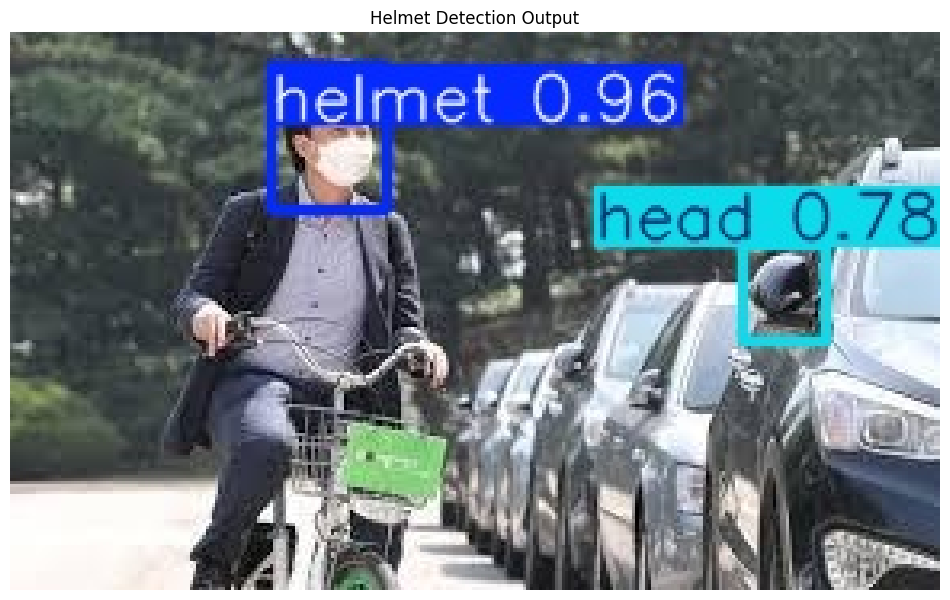

In [30]:
prediction_folder = Path("../runs/detect/helmet_predictions")

output_images = (
    list(prediction_folder.glob("*.jpg")) +
    list(prediction_folder.glob("*.png")) +
    list(prediction_folder.glob("*.jpeg"))
)

print("Output images:", len(output_images))

img_path = output_images[0]

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Helmet Detection Output")
plt.show()

In [31]:
outputs_folder = Path("../outputs")
outputs_folder.mkdir(exist_ok=True)

for i, img_path in enumerate(output_images[:15], start=1):
    shutil.copy(img_path, outputs_folder / f"helmet_detection_output_{i}{img_path.suffix}")

print("Output images copied to outputs folder")

Output images copied to outputs folder


In [32]:
detected_counts = Counter()

for result in prediction_results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = trained_model.names[class_id]
        detected_counts[class_name] += 1

print("Detected Object Count:")
print(detected_counts)

Detected Object Count:
Counter({'head': 658, 'person': 241, 'helmet': 100})


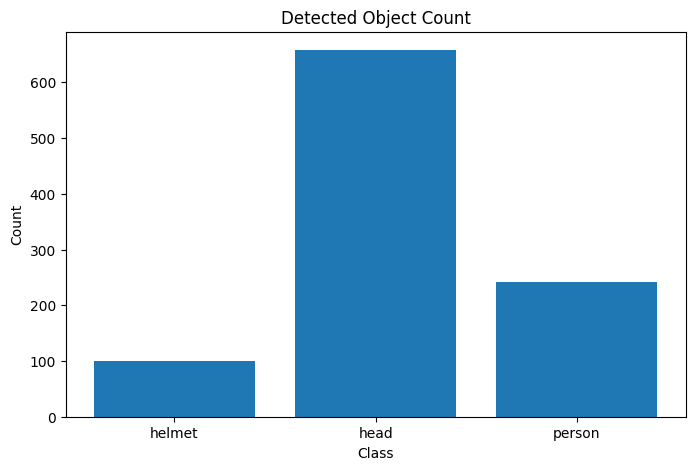

In [33]:
names = list(detected_counts.keys())
counts = list(detected_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(names, counts)
plt.title("Detected Object Count")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [34]:
confidence_data = []

for result in prediction_results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = trained_model.names[class_id]
        confidence = float(box.conf[0])

        confidence_data.append({
            "class": class_name,
            "confidence": confidence
        })

confidence_df = pd.DataFrame(confidence_data)

confidence_df.head()

,class,confidence
0,helmet,0.962473
1,head,0.782872
2,head,0.651010
3,helmet,0.736335
4,helmet,0.970051


In [35]:
avg_confidence = confidence_df.groupby("class")["confidence"].mean().reset_index()

print(avg_confidence)

    class  confidence
0    head    0.751277
1  helmet    0.670864
2  person    0.801188


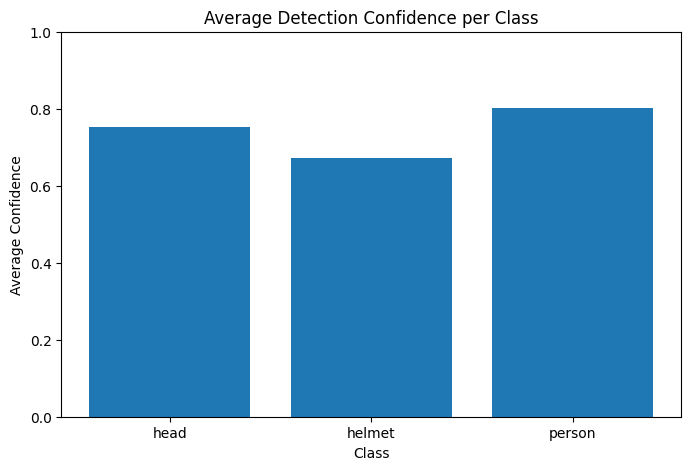

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(avg_confidence["class"], avg_confidence["confidence"])
plt.title("Average Detection Confidence per Class")
plt.xlabel("Class")
plt.ylabel("Average Confidence")
plt.ylim(0, 1)
plt.show()

In [37]:
confidence_df.to_csv("../outputs/detection_confidence_report.csv", index=False)

print("CSV report saved in outputs folder")

CSV report saved in outputs folder


In [38]:
results_csv_path = "../runs/detect/helmet_detection_advanced/results.csv"

training_df = pd.read_csv(results_csv_path)

training_df.head()

,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,1.5521,2.2898,1.4333,0.23240,0.45420,0.26999,0.16640,1.2691,4.0888,1.3339,0.067393,0.000329,0.000329
1,1,1.4370,1.4883,1.4468,0.73892,0.68050,0.74038,0.43998,1.4091,1.5038,1.4524,0.067393,0.000329,0.000329
2,2,1.3966,1.2654,1.3822,0.83585,0.74180,0.84925,0.52288,1.3425,1.2061,1.3827,0.034327,0.000597,0.000597
3,3,1.3724,1.2057,1.3905,0.87926,0.77332,0.87049,0.54702,1.2803,1.1925,1.3797,0.001196,0.000799,0.000799
4,4,1.3099,1.0869,1.3450,0.83823,0.77679,0.87135,0.54872,1.2981,1.0410,1.3607,0.000703,0.000703,0.000703


In [40]:
print(training_df.columns)

Index(['                  epoch', '         train/box_loss',
       '         train/cls_loss', '         train/dfl_loss',
       '   metrics/precision(B)', '      metrics/recall(B)',
       '       metrics/mAP50(B)', '    metrics/mAP50-95(B)',
       '           val/box_loss', '           val/cls_loss',
       '           val/dfl_loss', '                 lr/pg0',
       '                 lr/pg1', '                 lr/pg2'],
      dtype='object')


In [41]:
training_df.columns = training_df.columns.str.strip()
print(training_df.columns)

Index(['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


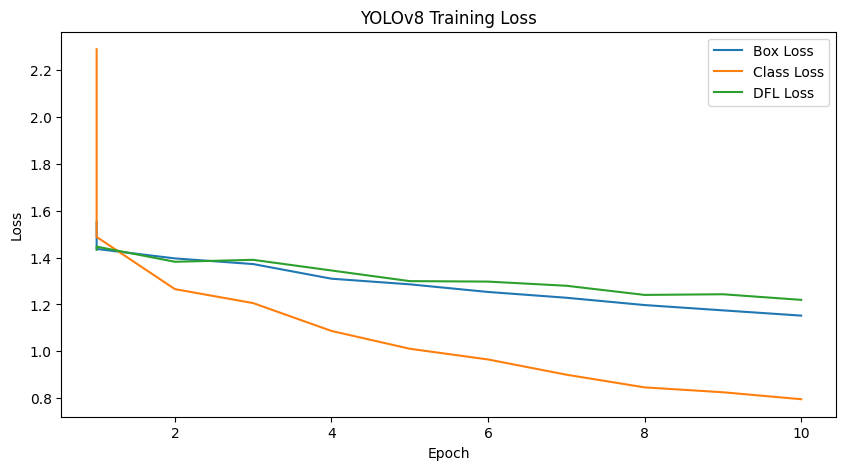

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(training_df["epoch"], training_df["train/box_loss"], label="Box Loss")
plt.plot(training_df["epoch"], training_df["train/cls_loss"], label="Class Loss")
plt.plot(training_df["epoch"], training_df["train/dfl_loss"], label="DFL Loss")
plt.title("YOLOv8 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

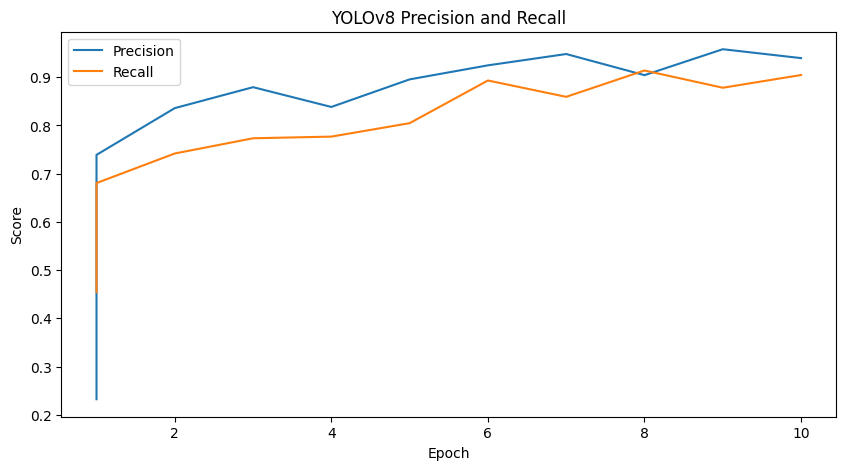

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(training_df["epoch"], training_df["metrics/precision(B)"], label="Precision")
plt.plot(training_df["epoch"], training_df["metrics/recall(B)"], label="Recall")
plt.title("YOLOv8 Precision and Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

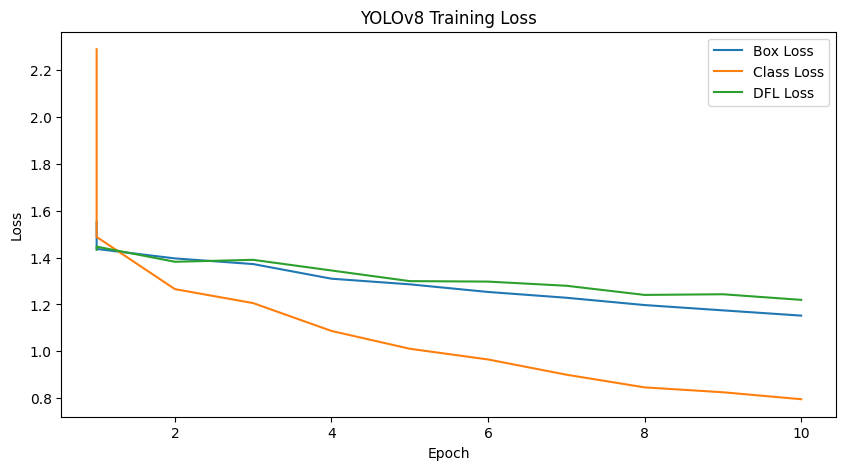

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(training_df["epoch"], training_df["train/box_loss"], label="Box Loss")
plt.plot(training_df["epoch"], training_df["train/cls_loss"], label="Class Loss")
plt.plot(training_df["epoch"], training_df["train/dfl_loss"], label="DFL Loss")
plt.title("YOLOv8 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

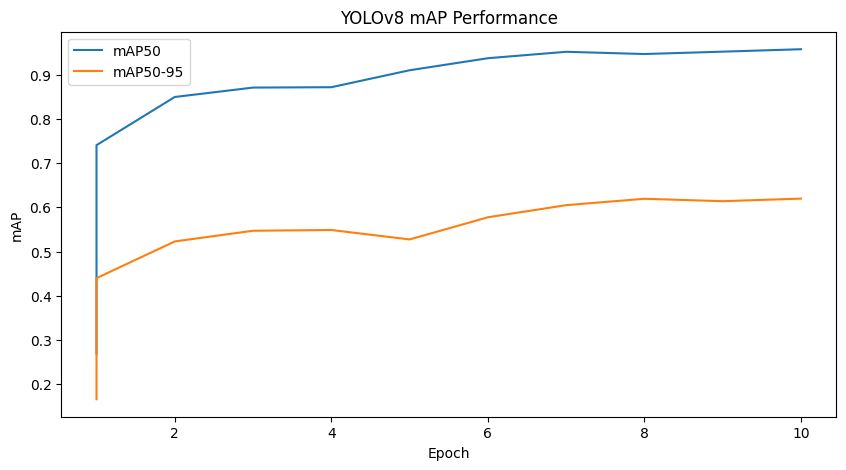

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(training_df["epoch"], training_df["metrics/mAP50(B)"], label="mAP50")
plt.plot(training_df["epoch"], training_df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.title("YOLOv8 mAP Performance")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.legend()
plt.show()

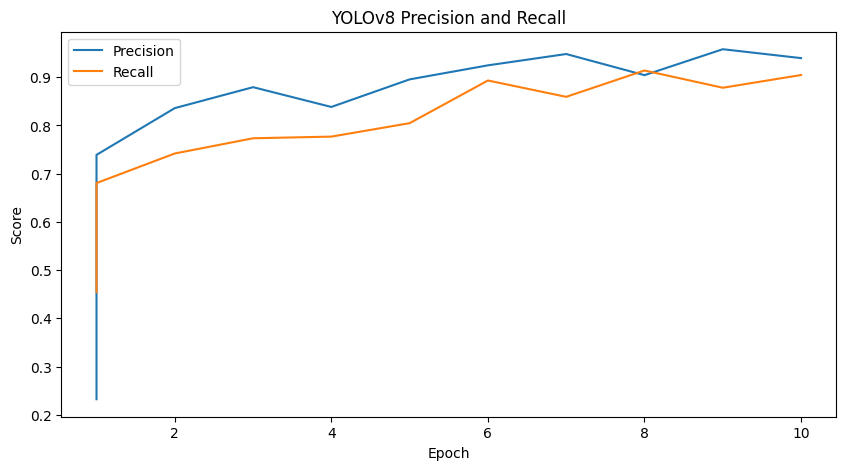

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(training_df["epoch"], training_df["metrics/precision(B)"], label="Precision")
plt.plot(training_df["epoch"], training_df["metrics/recall(B)"], label="Recall")
plt.title("YOLOv8 Precision and Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

In [47]:
single_image = list(Path("../test/images").glob("*"))[0]

single_result = trained_model.predict(
    source=str(single_image),
    conf=0.25,
    save=True,
    project="../runs/detect",
    name="single_image_prediction",
    exist_ok=True
)

print("Single image prediction completed")


image 1/1 e:\CODTECH_PROJECTS\Safety-Helmet-Detection-YOLOv8\notebooks\..\test\images\-1-_jpg.rf.be14331050a373b21f321a5c7d5aa0e2.jpg: 384x640 1 helmet, 1 head, 92.7ms
Speed: 3.0ms preprocess, 92.7ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
Results saved to ..\runs\detect\single_image_prediction
1 label saved to ..\runs\detect\single_image_prediction\labels
Single image prediction completed
